# InstructPix2Pix: Learning to Follow Image Editing Instructions

A demo notebook for [InstructPix2Pix](https://www.timothybrooks.com/instruct-pix2pix/) using [diffusers](https://github.com/huggingface/diffusers). InstructPix2Pix is fine-tuned stable diffusion model which allows you to edit images using language instructions.

<img src='https://instruct-pix2pix.timothybrooks.com/teaser.jpg'/>

In [ ]:
!pip install -qqq git+https://github.com/huggingface/diffusers.git gradio transformers accelerate safetensors

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Download the image for our example

In [ ]:
%%capture
!wget https://efrosgans.eecs.berkeley.edu/SwappingAutoencoder/results_for_paper_with_new_ffhq2/ffhq/stylegan2_rec/00001__000.png

Load the `StableDiffusionInstructPix2PixPipeline` pipeline

In [ ]:
import PIL
import requests
import torch
from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler

model_id = "timbrooks/instruct-pix2pix"
pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(model_id, torch_dtype=torch.float16, revision="fp16", safety_checker=None)
pipe.to("cuda")
pipe.enable_attention_slicing()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:335: FutureWarning: You are loading the variant fp16 from timbrooks/instruct-pix2pix via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that timbrooks/instruct-pix2pix currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'timbrooks/instruct-pix2pix is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_instruct_pix2pix.StableDiffusionInstructPix2PixPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Load the image

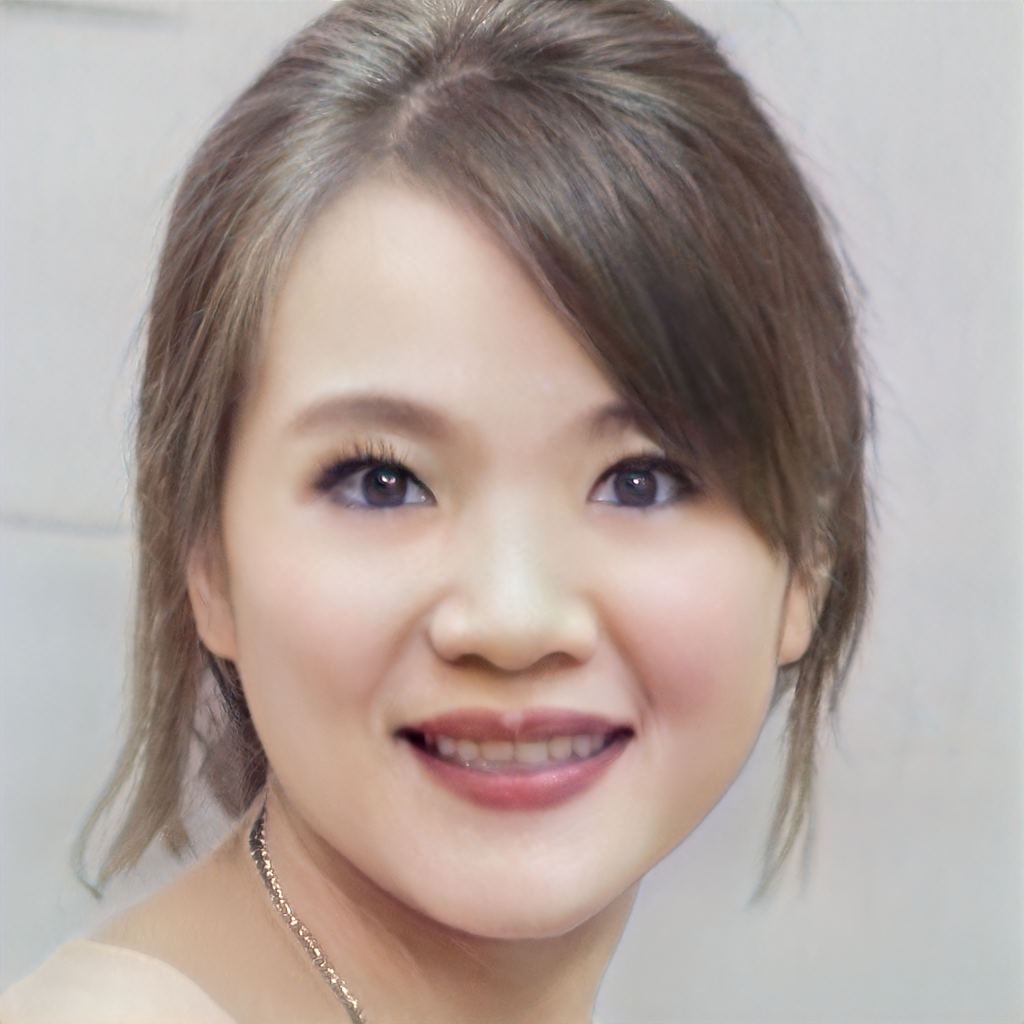

In [ ]:
image = PIL.Image.open("./00001__000.png")
image = PIL.ImageOps.exif_transpose(image)
image = image.convert("RGB")
image

In [ ]:
prompt = "Even out the complexion with foundation, shape the brows neatly, use a muted lip tint, and keep the style minimal yet refined."
pipe(prompt, image=image, num_inference_steps=20, image_guidance_scale=1).images[0]

In [ ]:
def edit_image(input_image: PIL.Image.Image, instruction: str):
    """
    Edits an image based on a text instruction using the InstructPix2Pix pipeline.

    Args:
        input_image: The input PIL Image to be edited.
        instruction: The text instruction for the edit.

    Returns:
        A PIL Image of the edited image.
    """
    # Use the previously loaded pipeline 'pipe'
    edited_image = pipe(
        instruction,
        image=input_image,
        num_inference_steps=20, # You can adjust these parameters as needed
        image_guidance_scale=1
    ).images[0]
    return edited_image

In [ ]:
#@title NOT USED NOW - FROM GRADIO DEMO
from __future__ import annotations

import math
import random

import gradio as gr
import torch
from PIL import Image, ImageOps
from diffusers import StableDiffusionInstructPix2PixPipeline


help_text = """
If you're not getting what you want, there may be a few reasons:
1. Is the image not changing enough? Your Image CFG weight may be too high. This value dictates how similar the output should be to the input. It's possible your edit requires larger changes from the original image, and your Image CFG weight isn't allowing that. Alternatively, your Text CFG weight may be too low. This value dictates how much to listen to the text instruction. The default Image CFG of 1.5 and Text CFG of 7.5 are a good starting point, but aren't necessarily optimal for each edit. Try:
    * Decreasing the Image CFG weight, or
    * Increasing the Text CFG weight, or
2. Conversely, is the image changing too much, such that the details in the original image aren't preserved? Try:
    * Increasing the Image CFG weight, or
    * Decreasing the Text CFG weight
3. Try generating results with different random seeds by setting "Randomize Seed" and running generation multiple times. You can also try setting "Randomize CFG" to sample new Text CFG and Image CFG values each time.
4. Rephrasing the instruction sometimes improves results (e.g., "turn him into a dog" vs. "make him a dog" vs. "as a dog").
5. Increasing the number of steps sometimes improves results.
6. Do faces look weird? The Stable Diffusion autoencoder has a hard time with faces that are small in the image. Try:
    * Cropping the image so the face takes up a larger portion of the frame.
"""


example_instructions = [
    "Make it a picasso painting",
    "as if it were by modigliani",
    "convert to a bronze statue",
    "Turn it into an anime.",
    "have it look like a graphic novel",
    "make him gain weight",
    "what would he look like bald?",
    "Have him smile",
    "Put him in a cocktail party.",
    "move him at the beach.",
    "add dramatic lighting",
    "Convert to black and white",
    "What if it were snowing?",
    "Give him a leather jacket",
    "Turn him into a cyborg!",
    "make him wear a beanie",
]

model_id = "timbrooks/instruct-pix2pix"

def main():
    pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(model_id, torch_dtype=torch.float16, revision="fp16", safety_checker=None).to("cuda")
    example_image = Image.open("./example.jpg").convert("RGB")

    def load_example(
        steps: int,
        randomize_seed: bool,
        seed: int,
        randomize_cfg: bool,
        text_cfg_scale: float,
        image_cfg_scale: float,
    ):
        example_instruction = random.choice(example_instructions)
        return [example_image, example_instruction] + generate(
            example_image,
            example_instruction,
            steps,
            randomize_seed,
            seed,
            randomize_cfg,
            text_cfg_scale,
            image_cfg_scale,
        )

    def generate(
        input_image: Image.Image,
        instruction: str,
        steps: int,
        randomize_seed: bool,
        seed: int,
        randomize_cfg: bool,
        text_cfg_scale: float,
        image_cfg_scale: float,
    ):
        seed = random.randint(0, 100000) if randomize_seed else seed
        text_cfg_scale = round(random.uniform(6.0, 9.0), ndigits=2) if randomize_cfg else text_cfg_scale
        image_cfg_scale = round(random.uniform(1.2, 1.8), ndigits=2) if randomize_cfg else image_cfg_scale

        width, height = input_image.size
        factor = 512 / max(width, height)
        factor = math.ceil(min(width, height) * factor / 64) * 64 / min(width, height)
        width = int((width * factor) // 64) * 64
        height = int((height * factor) // 64) * 64
        input_image = ImageOps.fit(input_image, (width, height))

        if instruction == "":
            return [input_image, seed]

        generator = torch.manual_seed(seed)
        edited_image = pipe(
            instruction, image=input_image,
            guidance_scale=text_cfg_scale, image_guidance_scale=image_cfg_scale,
            num_inference_steps=steps, generator=generator,
        ).images[0]
        return [seed, text_cfg_scale, image_cfg_scale, edited_image]

    def reset():
        return [0, "Randomize Seed", 1371, "Fix CFG", 7.5, 1.5, None]

    with gr.Blocks() as demo:
        with gr.Row():
            with gr.Column(scale=1, min_width=100):
                generate_button = gr.Button("Generate")
            with gr.Column(scale=1, min_width=100):
                load_button = gr.Button("Load Example")
            with gr.Column(scale=1, min_width=100):
                reset_button = gr.Button("Reset")
            with gr.Column(scale=3):
                instruction = gr.Textbox(lines=1, label="Edit Instruction", interactive=True)

        with gr.Row():
            input_image = gr.Image(label="Input Image", type="pil", interactive=True)
            edited_image = gr.Image(label=f"Edited Image", type="pil", interactive=False)
            input_image.style(height=512, width=512)
            edited_image.style(height=512, width=512)

        with gr.Row():
            steps = gr.Number(value=10, precision=0, label="Steps", interactive=True)
            randomize_seed = gr.Radio(
                ["Fix Seed", "Randomize Seed"],
                value="Randomize Seed",
                type="index",
                show_label=False,
                interactive=True,
            )
            seed = gr.Number(value=1371, precision=0, label="Seed", interactive=True)
            randomize_cfg = gr.Radio(
                ["Fix CFG", "Randomize CFG"],
                value="Fix CFG",
                type="index",
                show_label=False,
                interactive=True,
            )
            text_cfg_scale = gr.Number(value=7.5, label=f"Text CFG", interactive=True)
            image_cfg_scale = gr.Number(value=1.5, label=f"Image CFG", interactive=True)

        gr.Markdown(help_text)

        load_button.click(
            fn=load_example,
            inputs=[
                steps,
                randomize_seed,
                seed,
                randomize_cfg,
                text_cfg_scale,
                image_cfg_scale,
            ],
            outputs=[input_image, instruction, seed, text_cfg_scale, image_cfg_scale, edited_image],
        )
        generate_button.click(
            fn=generate,
            inputs=[
                input_image,
                instruction,
                steps,
                randomize_seed,
                seed,
                randomize_cfg,
                text_cfg_scale,
                image_cfg_scale,
            ],
            outputs=[seed, text_cfg_scale, image_cfg_scale, edited_image],
        )
        reset_button.click(
            fn=reset,
            inputs=[],
            outputs=[steps, randomize_seed, seed, randomize_cfg, text_cfg_scale, image_cfg_scale, edited_image],
        )

    demo.launch(share=True, debug=True)


if __name__ == "__main__":
    main()


In [ ]:
import os
import PIL

def batch_edit_image(image_directory: str, prompts_file: str):
    """
    Edits images from a directory based on prompts from a text file and saves the edited images.

    Args:
        image_directory: The path to the directory containing the input images.
        prompts_file: The path to the text file containing prompts, one prompt per line.
    """
    if not os.path.exists(prompts_file) or not os.path.isfile(prompts_file):
        raise FileNotFoundError(f"Prompts file not found at: {prompts_file}")

    with open(prompts_file, 'r') as f:
        prompts = f.readlines()
    prompts = [prompt.strip() for prompt in prompts]

    if not os.path.exists(image_directory) or not os.path.isdir(image_directory):
        raise FileNotFoundError(f"Image directory not found at: {image_directory}")

    image_files = [f for f in os.listdir(image_directory) if os.path.isfile(os.path.join(image_directory, f))]

    if len(image_files) != len(prompts):
        raise ValueError("The number of image files does not match the number of prompts.")

    output_dir = "./output_ip2p"
    os.makedirs(output_dir, exist_ok=True)

    for image_file, prompt in zip(image_files, prompts):
        image_path = os.path.join(image_directory, image_file)
        try:
            image = PIL.Image.open(image_path)
            image = PIL.ImageOps.exif_transpose(image)
            image = image.convert("RGB")

            edited_image = edit_image(image, prompt)

            output_path = os.path.join(output_dir, image_file)
            edited_image.save(output_path)
        except Exception as e:
            print(f"Warning: Could not process image {image_file}. Error: {e}")
            continue # Continue to the next image

In [ ]:
# Specify the input image directory and prompts file
image_directory = "./original_10"
prompts_file = "./prompts_10.txt"

# Run the batch editing process
batch_edit_image(image_directory, prompts_file)

print(f"Batch editing complete. Edited images are saved in the './output_ip2p' directory.")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Batch editing complete. Edited images are saved in the './output_ip2p' directory.


## LPIPS


In [ ]:
!pip install -qqq lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
import lpips
import torch
import PIL
import os

In [ ]:
import torchvision.transforms

In [ ]:
def LPIPS_evaluate(output_dir: str, reference_dir: str):
    """
    Compares images in two directories using the LPIPS metric.

    Args:
        output_dir: The path to the directory containing the output images.
        reference_dir: The path to the directory containing the reference images.

    Returns:
        A list of computed LPIPS scores.
    """
    # Initialize the LPIPS model
    loss_fn_alex = lpips.LPIPS(net='alex')

    # Move the model to the GPU if available
    if torch.cuda.is_available():
        loss_fn_alex.cuda()

    # Get sorted lists of image file names from both directories
    output_files = sorted(os.listdir(output_dir))
    reference_files = sorted(os.listdir(reference_dir))

    # Create full file paths for each image
    output_image_paths = [os.path.join(output_dir, f) for f in output_files]
    reference_image_paths = [os.path.join(reference_dir, f) for f in reference_files]

    # Check if the number of images in both directories is the same
    if len(output_image_paths) != len(reference_image_paths):
        raise ValueError("The number of images in the output and reference directories do not match.")

    # Create an empty list to store the LPIPS scores
    lpips_scores = []

    # Loop through the image files in both lists simultaneously
    for output_image_path, reference_image_path in zip(output_image_paths, reference_image_paths):
        # Load each image pair using PIL
        output_image = PIL.Image.open(output_image_path).convert("RGB")
        reference_image = PIL.Image.open(reference_image_path).convert("RGB")

        # Convert PIL images to PyTorch tensors and preprocess
        # LPIPS expects tensors in range [-1, 1] and shape (N, C, H, W)
        to_tensor = torchvision.transforms.ToTensor()

        output_tensor = to_tensor(output_image)
        reference_tensor = to_tensor(reference_image)

        # Normalize to [-1, 1]
        output_tensor = output_tensor * 2. - 1.
        reference_tensor = reference_tensor * 2. - 1.

        # Add batch dimension
        output_tensor = output_tensor.unsqueeze(0)
        reference_tensor = reference_tensor.unsqueeze(0)

        # Move tensors to the GPU if available
        if torch.cuda.is_available():
            output_tensor = output_tensor.cuda()
            reference_tensor = reference_tensor.cuda()

        # Compute the LPIPS score
        with torch.no_grad(): # Disable gradient calculation for inference
            score_tensor = loss_fn_alex(output_tensor, reference_tensor)

        # Extract the scalar value and append to the list
        lpips_scores.append(score_tensor.item())

    # Return the list of LPIPS scores
    return lpips_scores

In [ ]:
# Specify the output and reference directories
output_directory = "./output_ip2p"
reference_directory = "./ref_10"

# Evaluate the images using LPIPS
lpips_scores = LPIPS_evaluate(output_directory, reference_directory)

# Print or display the LPIPS scores
print("LPIPS scores for each image pair:")
display(lpips_scores)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:06<00:00, 35.9MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS scores for each image pair:


[0.7585428953170776,
 0.5249966979026794,
 0.41607359051704407,
 0.6802530884742737,
 0.6669697761535645,
 0.5990763306617737,
 0.6322494745254517,
 0.6703701019287109,
 0.5203826427459717,
 0.6205501556396484]

# FID

In [ ]:
!pip install -qqq pytorch-fid

In [ ]:
import torch
import numpy as np
from pytorch_fid import fid_score

In [ ]:
def evaluate_FID(output_dir: str, reference_dir: str):
    """
    Calculates the Fréchet Inception Distance (FID) between image sets in two directories.

    Args:
        output_dir: The path to the directory containing the generated images.
        reference_dir: The path to the directory containing the reference images.

    Returns:
        The computed FID score.
    """
    # Get lists of image file names from both directories
    output_files = os.listdir(output_dir)
    reference_files = os.listdir(reference_dir)

    # Create full file paths for each image
    output_image_paths = [os.path.join(output_dir, f) for f in output_files]
    reference_image_paths = [os.path.join(reference_dir, f) for f in reference_files]

    # Check if the number of images in both directories is the same
    if len(output_image_paths) != len(reference_image_paths):
        raise ValueError("The number of images in the output and reference directories do not match.")

    # Determine the device to use
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Compute the FID score
    fid_score_value = fid_score.calculate_fid_given_paths(
        [output_dir, reference_dir], # Pass directory paths directly
        batch_size=64, # Adjust batch size as needed
        device=device,
        dims=2048,
        num_workers=0 # Set to 0 for debugging or small datasets
    )

    return fid_score_value

In [ ]:
# Specify the output and reference directories
output_directory = "./output_ip2p"
reference_directory = "./ref_10"

# Evaluate the images using FID
fid_score_value = evaluate_FID(output_directory, reference_directory)

# Print or display the FID score
print("FID score:")
display(fid_score_value)

100%|██████████| 1/1 [00:00<00:00,  8.89it/s]


100%|██████████| 1/1 [00:00<00:00,  8.54it/s]


FID score:


np.float64(264.8532255879064)